<p style="font-size:300%; text-align:center"> king county housing price modeling</p>
<p style="font-size:150%; text-align:center"> modelling</p>

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium 
plt.style.use('ggplot')

##  Read the clean KC housing data

In [2]:
kc = pd.read_csv('data/kc_house_data_clean.csv')
#kc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21399 entries, 0 to 21398
Data columns (total 20 columns):
id               21399 non-null int64
date             21399 non-null object
price            21399 non-null int64
bedrooms         21399 non-null int64
bathrooms        21399 non-null float64
sqft_lot         21399 non-null float64
floors           21399 non-null float64
waterfront       21399 non-null float64
view             21399 non-null float64
condition        21399 non-null int64
grade            21399 non-null int64
sqft_above       21399 non-null float64
sqft_basement    21399 non-null float64
yr_built         21399 non-null int64
yr_renovated     21399 non-null int64
zipcode          21399 non-null int64
lat              21399 non-null float64
long             21399 non-null float64
sqft_living15    21399 non-null float64
sqft_lot15       21399 non-null float64
dtypes: float64(11), int64(8), object(1)
memory usage: 3.3+ MB


In [3]:
'''
price in $ span a large range of numbers while all the features has quite short range. It could be better to take the log
scale of the price before fitting.
also drop id 
'''
kc = kc.drop(["id"], axis=1)
kc['price'] = np.log(kc['price'])


## baseline model
To better gauage the progress let's model without any change to the features


In [4]:
# import statistical libraries for modelling. 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

### simple linear regression
It maybe worthwhile to investigate correlation between each individual feature with the outcome, which is the price 

In [5]:
kc.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [6]:
# using OLS of statsmodels.formula.api
tmp_y = kc[["price"]]
tmp_X = kc.drop(["price", "date"], axis=1)
predictors = tmp_X.columns

cols = ['feature', 'intercept',
        'slope', 'p-value', 'r_squared', 'F_p-value']
results = pd.DataFrame(columns=cols)
for idx, val in enumerate(predictors):
    #print("formula = price ~ "+val)
    f = 'price ~ ' + val
    model = ols(formula=f, data=kc).fit()
    results = results.append(pd.Series([val, model.params[0], model.params[1],
                                        model.pvalues[1], model.rsquared, model.f_pvalue], index=cols), ignore_index=True)
    # print(model.summary())

results = results.round(3)
print(results.sort_values(by=['slope'], ascending=False))

          feature  intercept  slope  p-value  r_squared  F_p-value
13            lat    -65.896  1.660      0.0      0.212        0.0
4      waterfront     13.028  0.782      0.0      0.012        0.0
1       bathrooms     12.295  0.351      0.0      0.274        0.0
7           grade     10.740  0.300      0.0      0.465        0.0
3          floors     12.607  0.285      0.0      0.094        0.0
14           long     39.039  0.213      0.0      0.004        0.0
5            view     12.987  0.207      0.0      0.092        0.0
0        bedrooms     12.399  0.188      0.0      0.114        0.0
6       condition     12.938  0.028      0.0      0.001        0.0
10       yr_built     10.193  0.001      0.0      0.007        0.0
12        zipcode     42.520 -0.000      0.0      0.001        0.0
15  sqft_living15     12.148  0.000      0.0      0.358        0.0
8      sqft_above     12.395  0.000      0.0      0.326        0.0
11   yr_renovated     13.023  0.000      0.0      0.009       

The R2 values of most of the features are small. The p-values are zero or very small, which shows that fitting parameters are dtatistically accurate. 

### multiple linear regression

In [7]:
tmp_kc = kc.drop(["date"], axis=1) # obviously date datatype won't work with OLS  
predictors = list(tmp_kc.columns)
predictors.remove('price')

f = 'price ~ ' + ' + '.join(predictors)       
model_0 = ols(formula=f, data=tmp_kc).fit()
print(model_0.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     3785.
Date:                Mon, 11 May 2020   Prob (F-statistic):               0.00
Time:                        14:48:40   Log-Likelihood:                -694.45
No. Observations:               21399   AIC:                             1425.
Df Residuals:                   21381   BIC:                             1568.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -5.9318      3.659     -1.621

The R2 values of 0.750 from statsmodels.formula.api OLS algorith is much more realistic and reasonable without handling the categorical data and without normalization of any king.

In [8]:
# k-fold cross validation
y = tmp_kc[["price"]].iloc[:,0].values
X = tmp_kc.drop(["price"], axis=1).iloc[:,0:].values

linreg = LinearRegression()
scores  = np.mean(cross_val_score(linreg, X, y, cv=5 ))
#,  scoring='neg_mean_squared_error'
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

Accuracy: 0.747 (+/- 0.000)


## Categorical and Numerical features
The categorical and numerical data must be handled appropriately. Some features such as date sold may be binned into seasons, which makes it easier to handle and much less complicated when fitting. Then all other numerical data may be normalized so that much more reasonable fitting parameters may be obtained when fitting. 

### Latitude and Longitude is inherently  correlated and cannot be treated separately

The zipcode, latitude and longitude all shows the location. While zipcode represents a region and inherently a categorical feature. The latitude+longitude is a much more precise measure of location of a given house. While in a single zipcode there may be a wide range of prices in the close neighborhood prices tend to be similar. Although latitude and longitude separately do not provide much useful information, it can be used to calculate distances relative to a fix point in the region. It should be noted that latitude and longitude are essentially angles and need quite complex conversions to transform them to distances. However, for a small enough region and a county they can be approximated to coordinates in a flat plane without loss of generality. The focal point that makes most sense is the official coordinates of Seattle, which is (47.6062, -122.3321). The ‘-’ on longitude represents ‘west’. For a house with coordinates (x1, y1) by applying ‘haversine’ formula for the distance ‘r’ can be calculated as follows 

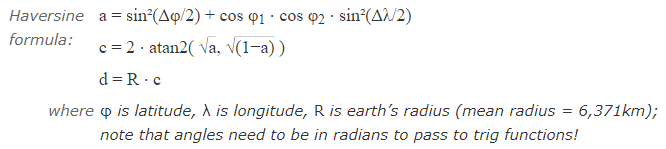

[haversine formula source](https://www.movable-type.co.uk/scripts/latlong.html)


In [9]:
def Cal_dist(lat2, lon2):
    #lat2=47.5112; lon2=-122.257
    lat1=47.6062; lon1=122.3321 # Seattel
    R = 6371*10^3; # in meters
    φ1 = lat1 * np.pi/180; # φ, λ in radians
    φ2 = lat2 * np.pi/180;
    Δφ = (lat2-lat1) * np.pi/180;
    Δλ = (lon2-lon1) * np.pi/180;

    a = np.sin(Δφ/2) * np.sin(Δφ/2) + np.cos(φ1) * np.cos(φ2) * np.sin(Δλ/2) * np.sin(Δλ/2);
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a));

    d = (R * c )/1000; # in kilo metres km
    return d
    
print(Cal_dist(47.5112, -122.257))

77.348990250629


In [10]:
kc['dist'] = kc.apply(lambda row: Cal_dist(row.lat, row.long) , axis=1)
display(kc[['lat', 'long', 'dist']].head())
#print(kc.columns)

,lat,long,dist
0,47.5112,-122.257,77.348990
1,47.7210,-122.319,77.141575
2,47.7379,-122.233,77.169163
3,47.5208,-122.393,77.274453
4,47.6168,-122.045,77.362968


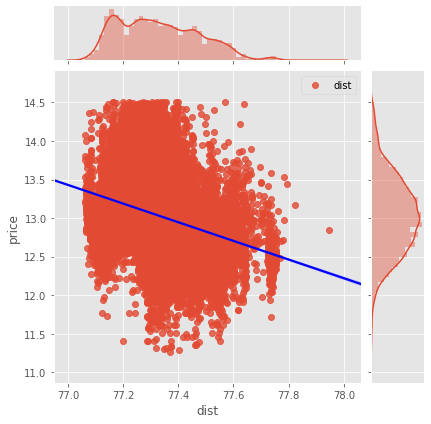

In [11]:
tmp_df=kc[['price', 'dist']]
headers=tmp_df.columns

sns.jointplot(x='dist', y="price", 
              data=tmp_df, #
              kind='reg', 
              label='dist', 
              joint_kws={'line_kws':{'color':'blue'}}) #stylistic choices

plt.legend() #

plt.show()

In [12]:
# now let's redo the OLS by replacing lattitude and longitude, lat and long with 'r'
tmp_kc = kc.drop(["date", 'lat', 'long'], axis=1) # obviously date datatype won't work with OLS  
predictors = list(tmp_kc.columns)
predictors.remove('price')

f = 'price ~ ' + ' + '.join(predictors)       
model_1 = ols(formula=f, data=tmp_kc).fit()
print(model_1.summary())

# k-fold cross validation
y = tmp_kc[["price"]].iloc[:,0].values
X = tmp_kc.drop(["price"], axis=1).iloc[:,0:].values

linreg = LinearRegression()
scores  = np.mean(cross_val_score(linreg, X, y, cv=5 ))
#,  scoring='neg_mean_squared_error'
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     3689.
Date:                Mon, 11 May 2020   Prob (F-statistic):               0.00
Time:                        14:48:58   Log-Likelihood:                -1380.3
No. Observations:               21399   AIC:                             2795.
Df Residuals:                   21382   BIC:                             2930.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       231.7099      4.580     50.592

Relacing 'lat' and 'long' with 'dist' reduced the R2 from 0.747 to 0.731. Thus, it maybe useful to look at linear regression of each these features to have an accurate estimation. 

In [13]:
tmp_kc = kc[['price','zipcode', 'lat', 'long','dist']]
predictors = list(tmp_kc.columns)
predictors.remove('price')

cols = ['feature', 'intercept',
        'slope', 'p-value', 'r_squared', 'F_p-value']
results = pd.DataFrame(columns=cols)
for idx, val in enumerate(predictors):
    f = 'price ~ ' + val
    model = ols(formula=f, data=tmp_kc).fit()
    results = results.append(pd.Series([val, model.params[0], model.params[1],
                                        model.pvalues[1], model.rsquared, model.f_pvalue], index=cols), ignore_index=True)
    # print(model.summary())

results = results.round(3)
print(results.sort_values(by=['slope'], ascending = False))

   feature  intercept  slope  p-value  r_squared  F_p-value
1      lat    -65.896  1.660      0.0      0.212        0.0
2     long     39.039  0.213      0.0      0.004        0.0
0  zipcode     42.520 -0.000      0.0      0.001        0.0
3     dist    106.532 -1.209      0.0      0.121        0.0


<b> Is the predictor 'dist' better than lat+long or zipcode ?</b> 

It is very difficult to say. Interms of godness of fit clearly lattitude has the best correlation. and zipcode is the least favorite. But interms of the slope lattitude is the largest but dist is the second largest magnitude. It has the negative slope which makes sense because the further you go from the downtown the less expensive teh house going to be. 
 
Considering there factors of model_1 results 'dist' maybe removed. 

In [14]:
# Let's remove 'dist'
kc = kc.drop(['dist'], axis =1 )
#kc = kc.drop(['lat', 'long', 'zipcode'], axis =1 )

### Categorize 'Date' variable to show season   
The feature 'date' is the date the souse sold in king county. A date data type will not be included in the regression. Thus, it may be better to categorize the date into season. 

In [15]:
kc['date']= pd.to_datetime(kc['date']) 
kc['month'] = kc['date'].dt.month # add a month column to the dataframe
kc.month.unique()

array([10, 12,  2,  5,  6,  1,  4,  3,  7,  8, 11,  9], dtype=int64)

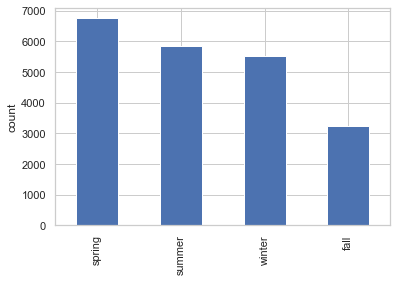

0          fall
1        winter
2        winter
3        winter
4        winter
          ...  
21394    spring
21395    winter
21396    spring
21397    winter
21398      fall
Name: season, Length: 21399, dtype: category
Categories (4, object): [winter, spring, summer, fall]

In [16]:
#plt.style.use('ggplot')
sns.set(style="whitegrid")
kc.month = kc.month.replace(12, 0) # change 12 to 0 so that 0-2 represent winter
#creating bins for the season
bins = [0, 3, 6, 9, 11]
kc['season'] = pd.cut(kc['month'], bins, include_lowest = True, labels = ["winter", "spring", "summer", "fall"])
kc['season'] = kc['season'].cat.as_unordered()
kc['season'].value_counts().plot(kind='bar')
plt.ylabel("count")
plt.savefig('img/season_histogram.png') # Save that figure
plt.show()
kc.season

### prepare other categorical features to sting   

In [17]:
#print(kc.columns[0:20])
check_cat = ['waterfront', 'condition', 'floors', 'view', 'grade', 'yr_renovated']
kc['waterfront'] = kc['waterfront'].astype("int")

for feature in check_cat:
    print("unique values of \'{}\' predictor".format(feature))
    display(kc[feature].value_counts())

unique values of 'waterfront' predictor


0    21296
1      103
Name: waterfront, dtype: int64

unique values of 'condition' predictor


3    13899
4     5631
5     1671
2      169
1       29
Name: condition, dtype: int64

unique values of 'floors' predictor


...

0.0    19415
2.0      930
3.0      483
1.0      317
4.0      254
Name: view, dtype: int64

unique values of 'grade' predictor


7     8973
8     6060
9     2597
6     2038
10    1075
11     329
5      242
12      56
4       27
13       1
3        1
Name: grade, dtype: int64

unique values of 'yr_renovated' predictor


0       20682
2014       73
2003       30
2013       30
2007       29
        ...  
1946        1
1953        1
1951        1
1948        1
1959        1
Name: yr_renovated, Length: 70, dtype: int64

The numerical variable looks catergorical. However, except wavefront rest can be assumed as a numerical data for the puspose of regression. 
let's encode wavefront onto string. 

In [18]:
#  change data type to string for hot coding 
kc['waterfront'] = kc['waterfront'].astype("str")

In [19]:
bins = [0, 1, 2015] #let's bin renovated and not_renovated
#since it looks like the majority of our houses were not renovated
bins_yr_renovated = pd.cut(kc['yr_renovated'], bins, include_lowest = True, labels = ["not_renovated", "renovated"])
kc['renovated'] = bins_yr_renovated.cat.as_unordered()
#kc.head()

In [20]:
# let's remove unnecessary and binned 
kc = kc.drop(['date','yr_renovated'], axis =1 )

### One-Hot Encoding to handle the categorical features 

In [21]:
kc = pd.get_dummies(kc) #one-hot encoding our data
kc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21399 entries, 0 to 21398
Data columns (total 25 columns):
price                      21399 non-null float64
bedrooms                   21399 non-null int64
bathrooms                  21399 non-null float64
sqft_lot                   21399 non-null float64
floors                     21399 non-null float64
view                       21399 non-null float64
condition                  21399 non-null int64
grade                      21399 non-null int64
sqft_above                 21399 non-null float64
sqft_basement              21399 non-null float64
yr_built                   21399 non-null int64
zipcode                    21399 non-null int64
lat                        21399 non-null float64
long                       21399 non-null float64
sqft_living15              21399 non-null float64
sqft_lot15                 21399 non-null float64
month                      21399 non-null int64
waterfront_0               21399 non-null uint8
water

In [22]:
#kc.rename(columns={'waterfront_0.0' : 'waterfront_0', 'waterfront_1.0' : 'waterfront_1'}, inplace=True)
kc.rename(columns={'renovated_renovated' : 'is_renovated'}, inplace=True)

In [23]:
# to preserve linear dependance let's drop one column from hot encoded features 
kc = kc.drop(['waterfront_0', 'season_fall','renovated_not_renovated'], axis =1 )

## Min-Max Normalization
Min-max normalization make most sense for this data. 


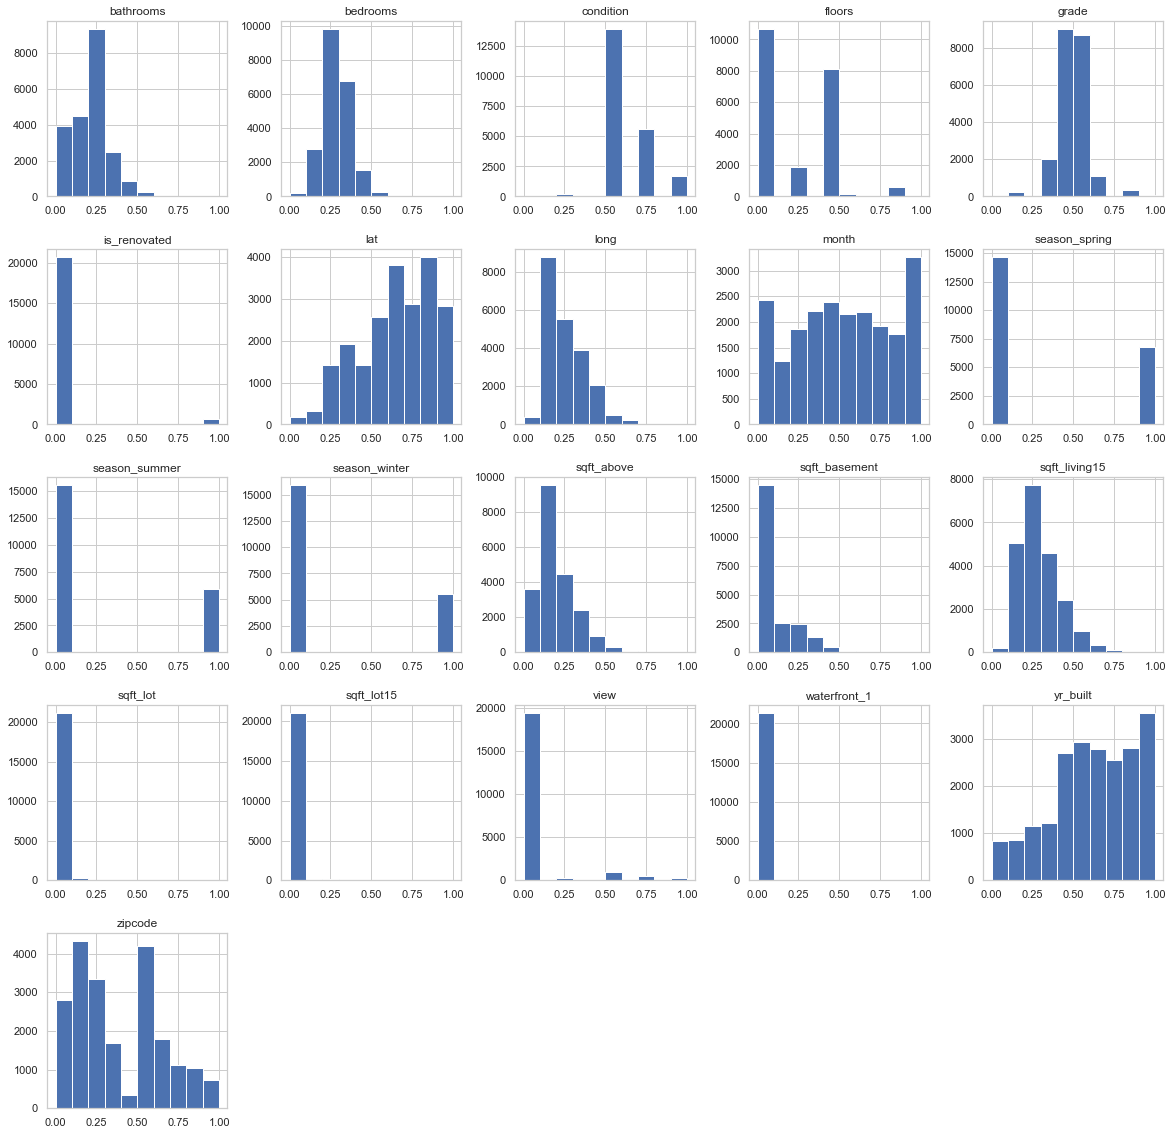

In [24]:
# min-max scaler (normalization using y= (x-min)/(max-min))
from sklearn.preprocessing import MinMaxScaler 

#let's drop the price for it's not included in the normalize
kc_norm = kc.drop(['price'], axis =1 )

scaler = MinMaxScaler() # instantiate 
kc_norm = pd.DataFrame(scaler.fit_transform(kc_norm), columns = kc_norm.columns)
kc_norm.hist(figsize = (20,20));

In [25]:
#display(kc_norm.columns)
# add the price column to the mean normalized dataset. 
#kc_norm['price']=kc['price']
kc_norm=pd.concat([kc['price'], kc_norm], axis=1)
#kc_norm=pd.concat([kc_cat, kc_norm], axis=1)
display(kc_norm.columns)

Index(['price', 'bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'view',
       'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'month',
       'waterfront_1', 'season_winter', 'season_spring', 'season_summer',
       'is_renovated'],
      dtype='object')

### Validation - Normality Check (Q-Q plots)

Now that variables are normalized let's validate the data. 

C:\Anaconda3\envs\learn-env\lib\site-packages\statsmodels\graphics\utils.py:56: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = plt.figure()
C:\Anaconda3\envs\learn-env\lib\site-packages\ipykernel_launcher.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  from ipykernel import kernelapp as app


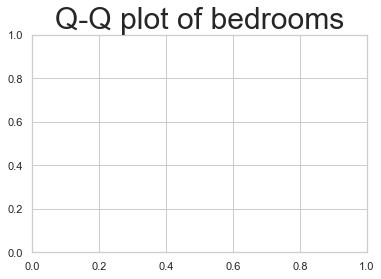

<Figure size 720x720 with 0 Axes>

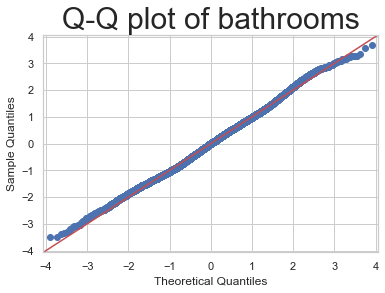

<Figure size 720x720 with 0 Axes>

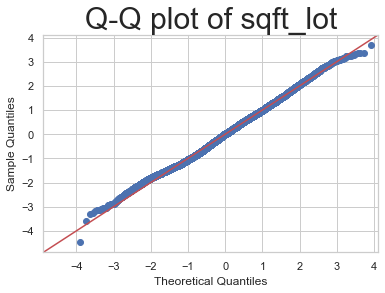

<Figure size 720x720 with 0 Axes>

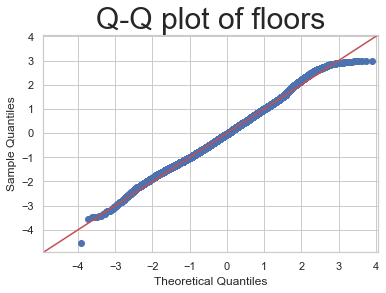

<Figure size 720x720 with 0 Axes>

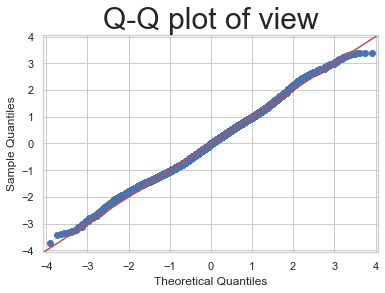

<Figure size 720x720 with 0 Axes>

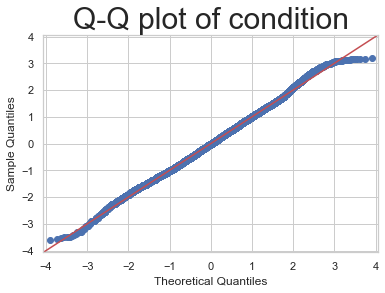

<Figure size 720x720 with 0 Axes>

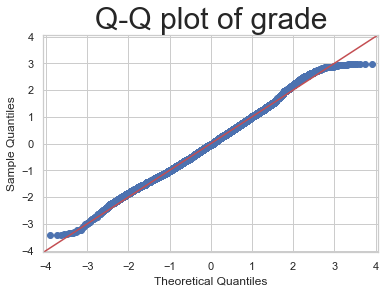

<Figure size 720x720 with 0 Axes>

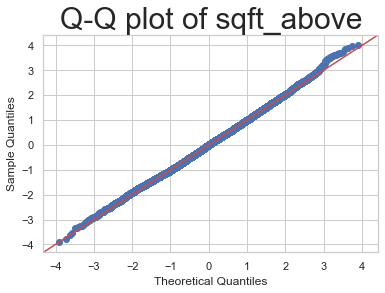

<Figure size 720x720 with 0 Axes>

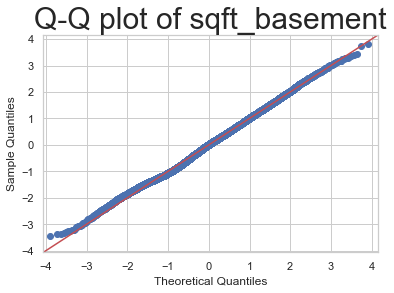

<Figure size 720x720 with 0 Axes>

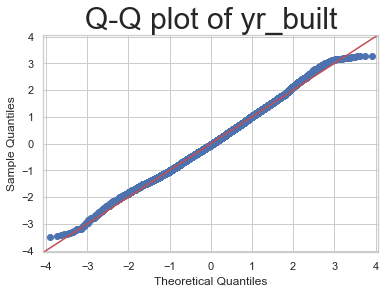

<Figure size 720x720 with 0 Axes>

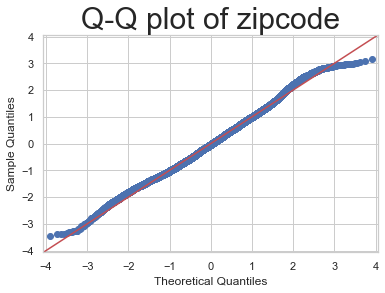

<Figure size 720x720 with 0 Axes>

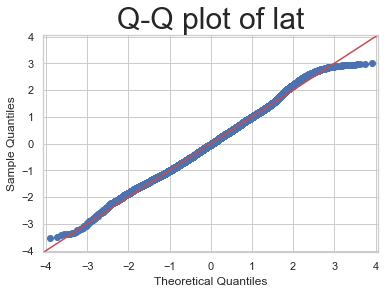

<Figure size 720x720 with 0 Axes>

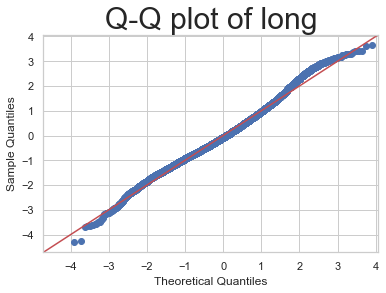

<Figure size 720x720 with 0 Axes>

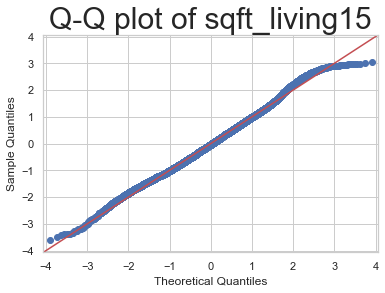

<Figure size 720x720 with 0 Axes>

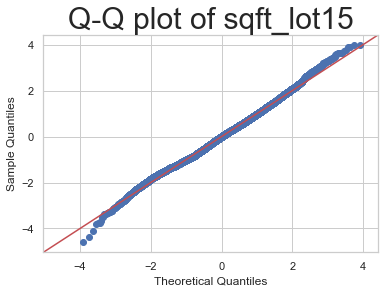

<Figure size 720x720 with 0 Axes>

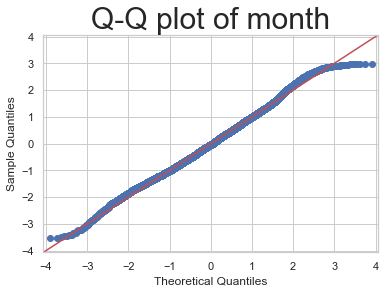

<Figure size 720x720 with 0 Axes>

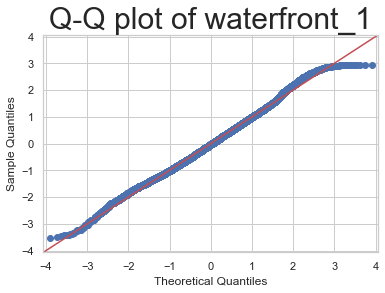

<Figure size 720x720 with 0 Axes>

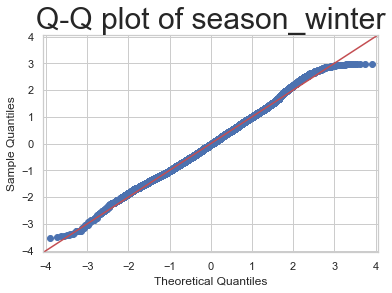

<Figure size 720x720 with 0 Axes>

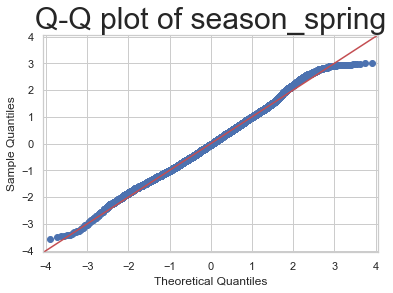

<Figure size 720x720 with 0 Axes>

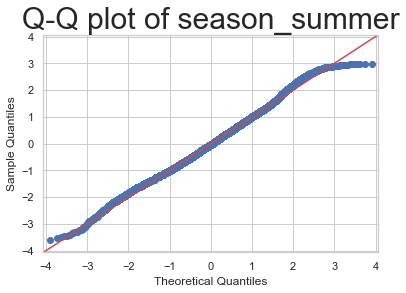

<Figure size 720x720 with 0 Axes>

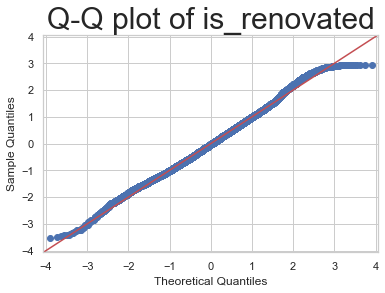

<Figure size 720x720 with 0 Axes>

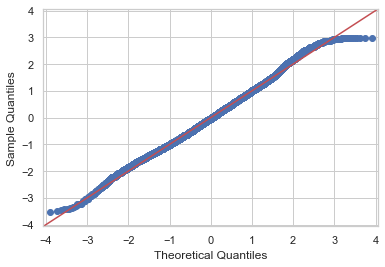

In [26]:
import statsmodels.stats.api as sms
import scipy.stats as stats

tmp_kc = kc_norm
predictors = list(tmp_kc.columns)
predictors.remove('price')

for i in range(len(predictors)):
    #print("formula = price ~ "+predictors[i])
    f = 'price ~ ' + predictors[i]       
    model = ols(formula=f, data=tmp_kc).fit()
    # get residue
    resid = model.resid
    plt.title('Q-Q plot of '+predictors[i],fontsize=30)
    fig = plt.figure(figsize=(10,10))
    fig = sm.graphics.qqplot(resid, dist=stats.norm, line='45', fit=True)
    #plt.show()

Q-Q plots look good. Normality is preserved in all features. 

### Let's redo OLS after normalization

In [27]:
# how does the fitting of each individual feature change after normalization  ? 

tmp_y = kc_norm[["price"]]
tmp_X = kc_norm.drop(["price"], axis=1)
predictors = tmp_X.columns

cols = ['feature', 'intercept',
        'slope', 'p-value', 'r_squared', 'F_p-value']
results = pd.DataFrame(columns=cols)
for idx, val in enumerate(predictors):
    #print("formula = price ~ "+val)
    f = 'price ~ ' + val
    model = ols(formula=f, data=kc).fit()
    results = results.append(pd.Series([val, model.params[0], model.params[1],
                                        model.pvalues[1], model.rsquared, model.f_pvalue], index=cols), ignore_index=True)
    # print(model.summary())

results = results.round(3)
print(results.sort_values(by=['slope'], ascending=False))

          feature  intercept  slope  p-value  r_squared  F_p-value
11            lat    -65.896  1.660    0.000      0.212      0.000
16   waterfront_1     13.028  0.782    0.000      0.012      0.000
1       bathrooms     12.295  0.351    0.000      0.274      0.000
6           grade     10.740  0.300    0.000      0.465      0.000
3          floors     12.607  0.285    0.000      0.094      0.000
20   is_renovated     13.023  0.266    0.000      0.009      0.000
12           long     39.039  0.213    0.000      0.004      0.000
4            view     12.987  0.207    0.000      0.092      0.000
0        bedrooms     12.399  0.188    0.000      0.114      0.000
18  season_spring     13.018  0.045    0.000      0.002      0.000
5       condition     12.938  0.028    0.000      0.001      0.000
9        yr_built     10.193  0.001    0.000      0.007      0.000
8   sqft_basement     12.940  0.000    0.000      0.080      0.000
7      sqft_above     12.395  0.000    0.000      0.326      0

In [28]:
# What's affect after hot-coding and normalization ? 
tmp_kc = kc_norm.drop(['month'], axis=1)
predictors = list(tmp_kc.columns)
predictors.remove('price')

f = 'price ~ ' + ' + '.join(predictors)       
model_2 = ols(formula=f, data=tmp_kc).fit()
print(model_2.summary())

# k-fold cross validation
y = tmp_kc[["price"]].iloc[:,0].values
X = tmp_kc.drop(["price"], axis=1).iloc[:,0:].values

linreg = LinearRegression()
scores  = np.mean(cross_val_score(linreg, X, y, cv=5 ))
#,  scoring='neg_mean_squared_error'
print("\n\n Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     3230.
Date:                Mon, 11 May 2020   Prob (F-statistic):               0.00
Time:                        14:50:12   Log-Likelihood:                -661.22
No. Observations:               21399   AIC:                             1364.
Df Residuals:                   21378   BIC:                             1532.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        11.3832      0.016    719.536

## Feature engineering - Stepwise feature selection
Let's feature engineer select from model_2 systematically. 

In [29]:
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.01, 
                       threshold_out = 0.05, 
                       verbose=True):
    """ Perform a forward-backward feature selection 
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features 
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.argmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [30]:
predictors=kc_norm.drop(['month', 'price'], axis=1)
target=kc_norm[["price"]]
result = stepwise_selection(predictors, target, verbose=True)
print('resulting features:')

C:\Anaconda3\envs\learn-env\lib\site-packages\numpy\core\fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


Add  sqft_above                     with p-value 0.0
Add  sqft_basement                  with p-value 0.0
Add  grade                          with p-value 0.0
Add  yr_built                       with p-value 0.0
Add  lat                            with p-value 0.0
Add  view                           with p-value 3.3003e-213
Add  bathrooms                      with p-value 6.21204e-103
Add  condition                      with p-value 1.46853e-89
Add  sqft_living15                  with p-value 1.32241e-86
Add  floors                         with p-value 1.62476e-61
Add  waterfront_1                   with p-value 2.08244e-43
Add  zipcode                        with p-value 3.22219e-37
Add  sqft_lot                       with p-value 2.82974e-15
Add  long                           with p-value 6.4317e-17
Add  is_renovated                   with p-value 9.65388e-14
Add  season_spring                  with p-value 6.14202e-12
Add  bedrooms                       with p-value 4.21968e-06
Add

In [31]:
print(result)

['sqft_above', 'sqft_basement', 'grade', 'yr_built', 'lat', 'view', 'bathrooms', 'condition', 'sqft_living15', 'floors', 'waterfront_1', 'zipcode', 'sqft_lot', 'long', 'is_renovated', 'season_spring', 'bedrooms', 'season_winter']


from the feature selection <b>'sqft_lot15'</b>, <b>'season_summer'</b> has been removed. For the p-values this is not surpricing. 

In [32]:
kc_final=pd.concat([kc_norm['price'], kc_norm[result]], axis=1)
#kc_final = kc_norm[result]
kc_final.head()

,price,sqft_above,sqft_basement,grade,yr_built,lat,view,bathrooms,condition,sqft_living15,floors,waterfront_1,zipcode,sqft_lot,long,is_renovated,season_spring,bedrooms,season_winter
0,12.309982,0.114894,0.000000,0.4,0.478261,0.571498,0.0,0.071429,0.5,0.174550,0.0,0.0,0.893939,0.003108,0.217608,0.0,0.0,0.2,0.0
1,13.195614,0.255319,0.122699,0.4,0.443478,0.908959,0.0,0.250000,0.5,0.239473,0.4,0.0,0.626263,0.004072,0.166113,1.0,0.0,0.2,1.0
2,12.100712,0.056738,0.000000,0.3,0.286957,0.936143,0.0,0.071429,0.5,0.430532,0.0,0.0,0.136364,0.005743,0.237542,0.0,0.0,0.1,1.0
3,13.311329,0.096454,0.279141,0.4,0.565217,0.586939,0.0,0.357143,1.0,0.178260,0.0,0.0,0.681818,0.002714,0.104651,0.0,0.0,0.3,1.0
4,13.142166,0.185816,0.000000,0.5,0.756522,0.741354,0.0,0.214286,0.5,0.259878,0.0,0.0,0.368687,0.004579,0.393688,0.0,0.0,0.2,1.0


In [33]:
# What's affect after feature engineering ? 
tmp_kc = kc_final
predictors = list(tmp_kc.columns)
predictors.remove('price')

f = 'price ~ ' + ' + '.join(predictors)       
model_3 = ols(formula=f, data=tmp_kc).fit()
print(model_3.summary())

# k-fold cross validation
y = tmp_kc[["price"]].iloc[:,0].values
X = tmp_kc.drop(["price"], axis=1).iloc[:,0:].values

linreg = LinearRegression()
scores  = np.mean(cross_val_score(linreg, X, y, cv=5 )) # 5-fold cross validation 
#,  scoring='neg_mean_squared_error'
print("\n\n Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     3588.
Date:                Mon, 11 May 2020   Prob (F-statistic):               0.00
Time:                        14:50:55   Log-Likelihood:                -664.65
No. Observations:               21399   AIC:                             1367.
Df Residuals:                   21380   BIC:                             1519.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        11.3854      0.016    733.808

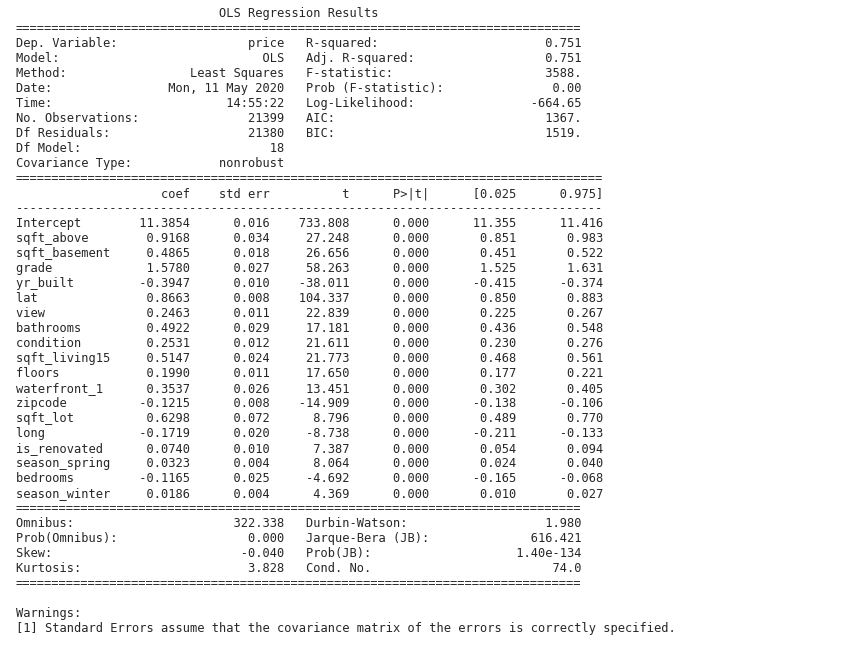

In [37]:
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(12, 7))
#plt.text(0.01, 0.05, str(model.summary()), {'fontsize': 12}) old approach
plt.text(0.01, 0.05, str(model_3.summary()), {'fontsize': 10}, fontproperties = 'monospace') # approach improved by OP -> monospace!
plt.axis('off')
plt.tight_layout()
plt.savefig('img/model_3_summary.png')


## Let's save the final model 
Save the clean data to a kc_house_data_clean.csv file

In [35]:
kc_final.to_csv('data/kc_house_final_model.csv', index=False)

<p style="font-size:200%; text-align:center">Please open analysis.ipynb next for data analysis and conclusions</p>